# 08 - Entraînement de SmallCNNv2

Ce notebook teste une version plus robuste de ton CNN maison :
- blocs `conv-conv-pool`
- `AdaptiveAvgPool2d`
- tête plus légère
- transformations raffinées
- weighted loss


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('SRC_DIR =', SRC_DIR)


PROJECT_ROOT = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification
SRC_DIR = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/src


In [2]:
from collections import Counter
import copy
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

from brain_tumor_mri.data.dataset import BrainMRIDataset
from brain_tumor_mri.data.split import make_train_val_split, describe_split
from brain_tumor_mri.models.cnn_small_v2 import SmallCNNv2
from brain_tumor_mri.training.engine import train_one_epoch, validate_one_epoch
from brain_tumor_mri.evaluation.metrics import compute_auprc
from brain_tumor_mri.utils import get_device, set_seed


In [3]:
CONFIG = {
    'seed': 42,
    'img_size': 224,
    'val_size': 0.20,
    'batch_size': 32,
    'num_workers': 2,
    'epochs': 14,
    'lr': 8e-4,
    'weight_decay': 1e-4,
    'class_weights': [1.0, 1.5],
    'checkpoint_name': 'best_smallcnn_v2.pt',
}
CONFIG


{'seed': 42,
 'img_size': 224,
 'val_size': 0.2,
 'batch_size': 32,
 'num_workers': 2,
 'epochs': 14,
 'lr': 0.0008,
 'weight_decay': 0.0001,
 'class_weights': [1.0, 1.5],
 'checkpoint_name': 'best_smallcnn_v2.pt'}

In [4]:
set_seed(CONFIG['seed'])
device = get_device()
TRAIN_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'brain_mri' / 'Training'
CHECKPOINT_PATH = PROJECT_ROOT / 'artifacts' / 'checkpoints' / CONFIG['checkpoint_name']
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
print(device, TRAIN_ROOT, CHECKPOINT_PATH)


cpu /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/data/raw/brain_mri/Training /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_smallcnn_v2.pt


In [5]:
train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.12, contrast=0.12),
    transforms.ToTensor(),
])

eval_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


In [6]:
full_dataset_labels = BrainMRIDataset(TRAIN_ROOT, transform=None)
labels = full_dataset_labels.get_labels()
train_idx, val_idx = make_train_val_split(labels=labels, val_size=CONFIG['val_size'], random_state=CONFIG['seed'])
describe_split([labels[i] for i in train_idx], name='train')
describe_split([labels[i] for i in val_idx], name='val')


train size = 2296
train distribution = Counter({1: 1980, 0: 316})
val size = 574
val distribution = Counter({1: 495, 0: 79})


In [7]:
full_train_aug = BrainMRIDataset(TRAIN_ROOT, transform=train_tfms)
full_train_eval = BrainMRIDataset(TRAIN_ROOT, transform=eval_tfms)
train_set = Subset(full_train_aug, train_idx)
val_set = Subset(full_train_eval, val_idx)
train_loader = DataLoader(train_set, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=CONFIG['num_workers'])
val_loader = DataLoader(val_set, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'])


In [8]:
model = SmallCNNv2(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(CONFIG['class_weights'], dtype=torch.float32).to(device))
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
print(model)


SmallCNNv2(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dila

In [9]:
history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_prauc': []}
best_prauc = -1.0
best_state = None

for epoch in range(CONFIG['epochs']):
    train_stats = train_one_epoch(model=model, loader=train_loader, criterion=criterion, optimizer=optimizer, device=device)
    val_stats = validate_one_epoch(model=model, loader=val_loader, criterion=criterion, device=device)
    val_prauc = compute_auprc(val_stats['targets'], val_stats['probs'])

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_stats['loss'])
    history['train_acc'].append(train_stats['acc'])
    history['val_loss'].append(val_stats['loss'])
    history['val_acc'].append(val_stats['acc'])
    history['val_prauc'].append(val_prauc)

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | train_acc={train_stats['acc']:.4f} | val_acc={val_stats['acc']:.4f} | val_prauc={val_prauc:.4f}")

    if val_prauc > best_prauc:
        best_prauc = val_prauc
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, CHECKPOINT_PATH)
        print('New best checkpoint saved.')


Epoch 1/14 | train_acc=0.8846 | val_acc=0.9059 | val_prauc=0.9843
New best checkpoint saved.


Epoch 2/14 | train_acc=0.9003 | val_acc=0.1585 | val_prauc=0.9537


Epoch 3/14 | train_acc=0.9159 | val_acc=0.5314 | val_prauc=0.9526


Epoch 4/14 | train_acc=0.9273 | val_acc=0.9181 | val_prauc=0.9901
New best checkpoint saved.


Epoch 5/14 | train_acc=0.9268 | val_acc=0.9007 | val_prauc=0.9894


...

Epoch 10/14 | train_acc=0.9334 | val_acc=0.9251 | val_prauc=0.9929


Epoch 11/14 | train_acc=0.9382 | val_acc=0.9321 | val_prauc=0.9956
New best checkpoint saved.


Epoch 12/14 | train_acc=0.9373 | val_acc=0.9303 | val_prauc=0.9964
New best checkpoint saved.


Epoch 13/14 | train_acc=0.9390 | val_acc=0.8972 | val_prauc=0.9948


Epoch 14/14 | train_acc=0.9364 | val_acc=0.9129 | val_prauc=0.9956


In [10]:
history_df = pd.DataFrame(history)
history_df.tail()


,epoch,train_loss,train_acc,val_loss,val_acc,val_prauc
9,10,0.139066,0.933362,0.152070,0.925087,0.992863
10,11,0.129597,0.938153,0.140936,0.932056,0.995555
11,12,0.126487,0.937282,0.128854,0.930314,0.996373
12,13,0.117421,0.939024,0.202707,0.897213,0.994802
13,14,0.125094,0.936411,0.186228,0.912892,0.995628


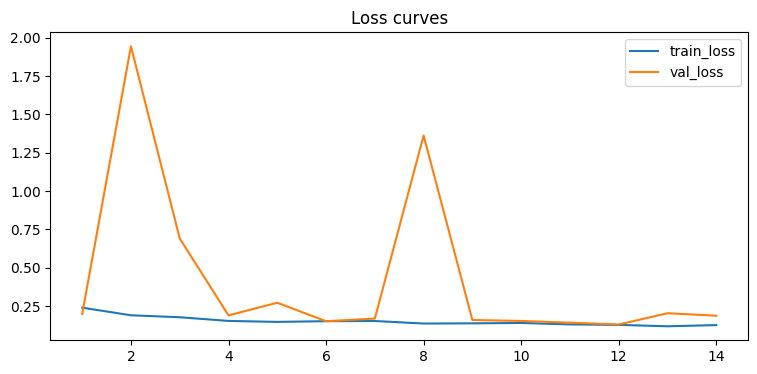

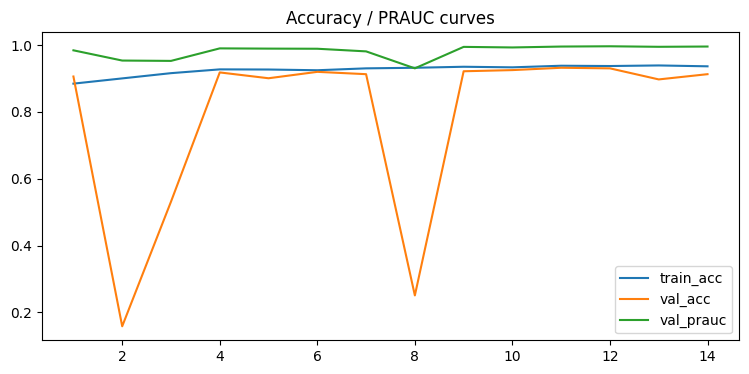

In [11]:
plt.figure(figsize=(9, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], label='train_loss')
plt.plot(history_df['epoch'], history_df['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss curves')
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(history_df['epoch'], history_df['train_acc'], label='train_acc')
plt.plot(history_df['epoch'], history_df['val_acc'], label='val_acc')
plt.plot(history_df['epoch'], history_df['val_prauc'], label='val_prauc')
plt.legend()
plt.title('Accuracy / PRAUC curves')
plt.show()


In [12]:
summary = {
    'checkpoint_path': str(CHECKPOINT_PATH),
    'best_val_prauc': float(best_prauc),
    'train_size': int(len(train_set)),
    'val_size': int(len(val_set)),
}
print(json.dumps(summary, indent=2))


{
  "checkpoint_path": "/home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_smallcnn_v2.pt",
  "best_val_prauc": 0.9963728917980471,
  "train_size": 2296,
  "val_size": 574
}


## Test

In [13]:
best_model = SmallCNNv2(num_classes=2).to(device)
best_model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
best_model.eval()

print("Best checkpoint reloaded from:", CHECKPOINT_PATH)

Best checkpoint reloaded from: /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_smallcnn_v2.pt


In [14]:
TEST_ROOT = PROJECT_ROOT / "data" / "raw" / "brain_mri" / "Testing"

test_set = BrainMRIDataset(TEST_ROOT, transform=eval_tfms)

print("Test size:", len(test_set))
print("Test distribution:", Counter(test_set.get_labels()))

Test size: 394
Test distribution: Counter({1: 289, 0: 105})


In [16]:
test_loader = DataLoader(
    test_set,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
)

print("Test batches:", len(test_loader))

Test batches: 13


In [17]:
test_stats = validate_one_epoch(
    model=best_model,
    loader=test_loader,
    criterion=criterion,
    device=device,
)

test_prauc = compute_auprc(test_stats["targets"], test_stats["probs"])

print("Test loss:", test_stats["loss"])
print("Test acc:", test_stats["acc"])
print("Test PRAUC:", test_prauc)

Test loss: 0.5349140779923667
Test acc: 0.6903553299492385
Test PRAUC: 0.9033634376578891


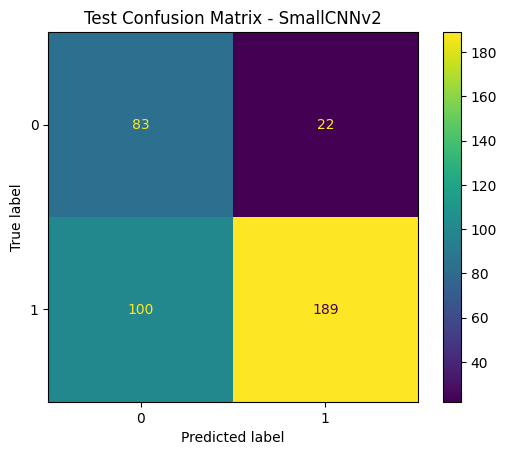

TN = 83
FP = 22
FN = 100
TP = 189


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_true_test = np.array(test_stats["targets"])
y_pred_test = np.array(test_stats["preds"])

cm = confusion_matrix(y_true_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Test Confusion Matrix - SmallCNNv2")
plt.show()

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

In [20]:
final_summary = {
    "checkpoint_path": str(CHECKPOINT_PATH),
    "train_size": int(len(train_set)),
    "val_size": int(len(val_set)),
    "test_size": int(len(test_set)),
    "epochs": CONFIG["epochs"],
    "best_val_prauc": float(best_prauc),
    "test_acc": float(test_stats["acc"]),
    "test_prauc": float(test_prauc),
    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),
}

print(json.dumps(final_summary, indent=2))

{
  "checkpoint_path": "/home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_smallcnn_v2.pt",
  "train_size": 2296,
  "val_size": 574,
  "test_size": 394,
  "epochs": 14,
  "best_val_prauc": 0.9963728917980471,
  "test_acc": 0.6903553299492385,
  "test_prauc": 0.9033634376578891,
  "TN": 83,
  "FP": 22,
  "FN": 100,
  "TP": 189
}


In [21]:
# Seuil 
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

for t in thresholds:
    y_pred_thresh = (np.array(test_stats["probs"]) >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true_test, y_pred_thresh).ravel()

    recall = tp / (tp + fn)
    precision = tp / (tp + fp)

    print(f"\nThreshold = {t}")
    print(f"Recall = {recall:.3f}")
    print(f"Precision = {precision:.3f}")
    print(f"FP = {fp}, FN = {fn}")


Threshold = 0.3
Recall = 0.986
Precision = 0.774
FP = 83, FN = 4

Threshold = 0.35
Recall = 0.962
Precision = 0.799
FP = 70, FN = 11

Threshold = 0.4
Recall = 0.924
Precision = 0.827
FP = 56, FN = 22

Threshold = 0.45
Recall = 0.869
Precision = 0.831
FP = 51, FN = 38

Threshold = 0.5
Recall = 0.654
Precision = 0.896
FP = 22, FN = 100


Le modèle SmallCNNv2 présente une meilleure capacité de discrimination globale (PRAUC élevé), mais nécessite un ajustement du seuil de décision.

Un seuil de 0.4 permet d’obtenir un compromis optimal entre sensibilité (Recall ≈ 92%) et précision (≈ 82%), tout en réduisant significativement les faux négatifs par rapport au seuil standard de 0.5.

Cela montre que l’architecture améliore la qualité des scores, mais que la calibration du seuil est essentielle pour une utilisation en contexte médical.

# Ajout de TTA 

In [22]:
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [23]:
tta_transforms = [
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(5),
        transforms.ToTensor(),
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.CenterCrop(210),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ]),
]

In [25]:
def predict_probabilities_tta(model, dataset, device, tta_transforms):
    model.eval()

    all_targets = []
    all_probs = []

    for path, target in dataset.samples:
        img = Image.open(path).convert("RGB")

        probs_per_view = []

        for tta_tfms in tta_transforms:
            x = tta_tfms(img).unsqueeze(0).to(device)

            with torch.no_grad():
                logits = model(x)
                probs = torch.softmax(logits, dim=1)[0, 1].item()

            probs_per_view.append(probs)

        mean_prob = float(np.mean(probs_per_view))

        all_targets.append(target)
        all_probs.append(mean_prob)

    return np.array(all_targets), np.array(all_probs)

In [26]:
y_true_tta, y_probs_tta = predict_probabilities_tta(
    model=best_model,
    dataset=test_set,
    device=device,
    tta_transforms=tta_transforms,
)

print("TTA done.")
print("Probabilities range:", y_probs_tta.min(), "->", y_probs_tta.max())

TTA done.
Probabilities range: 0.17529234662652016 -> 0.9995793700218201


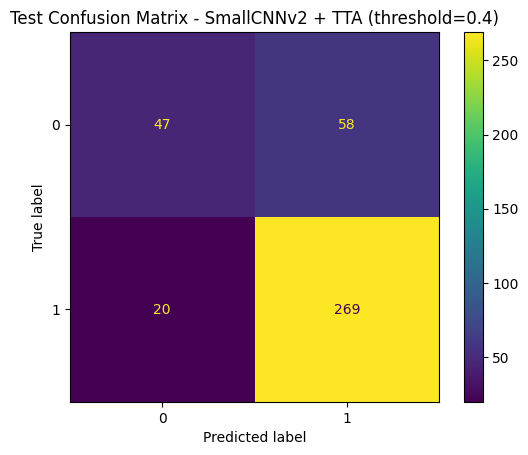

TN = 47
FP = 58
FN = 20
TP = 269
              precision    recall  f1-score   support

           0     0.7015    0.4476    0.5465       105
           1     0.8226    0.9308    0.8734       289

    accuracy                         0.8020       394
   macro avg     0.7621    0.6892    0.7099       394
weighted avg     0.7903    0.8020    0.7863       394



In [27]:
threshold = 0.4
y_pred_tta = (y_probs_tta >= threshold).astype(int)

cm = confusion_matrix(y_true_tta, y_pred_tta)
tn, fp, fn, tp = cm.ravel()

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Test Confusion Matrix - SmallCNNv2 + TTA (threshold={threshold})")
plt.show()

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

print(classification_report(y_true_tta, y_pred_tta, digits=4))

In [28]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

results_tta = []

for t in thresholds:
    y_pred = (y_probs_tta >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_tta, y_pred).ravel()

    precision = precision_score(y_true_tta, y_pred, zero_division=0)
    recall = recall_score(y_true_tta, y_pred, zero_division=0)
    f1 = f1_score(y_true_tta, y_pred, zero_division=0)

    results_tta.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })

results_tta_df = pd.DataFrame(results_tta)
results_tta_df

,threshold,precision,recall,f1,TN,FP,FN,TP
0,0.30,0.778689,0.986159,0.870229,24,81,4,285
1,0.35,0.796034,0.972318,0.875389,33,72,8,281
2,0.40,0.822630,0.930796,0.873377,47,58,20,269
3,0.45,0.830065,0.878893,0.853782,53,52,35,254
4,0.50,0.886878,0.678201,0.768627,80,25,93,196


In [29]:
best_tta_row = results_tta_df.sort_values("f1", ascending=False).iloc[0].to_dict()

print("Best TTA setup by F1:")
print(json.dumps(best_tta_row, indent=2))

Best TTA setup by F1:
{
  "threshold": 0.35,
  "precision": 0.7960339943342776,
  "recall": 0.972318339100346,
  "f1": 0.8753894080996885,
  "TN": 33.0,
  "FP": 72.0,
  "FN": 8.0,
  "TP": 281.0
}


TTA améliore légèrement la détection des tumeurs,
sans dégrader fortement la précision.